## Objective

The objective of this project is to analyze the Superstore Sales dataset and identify key business insights related to sales, profit, products, categories, regions, and discount strategies using exploratory data analysis and data visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("SuperStore_Orders.csv", encoding="latin1")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01-01-2011,06-01-2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,01-01-2011,05-01-2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,01-01-2011,05-01-2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [3]:
df.shape

(51290, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [5]:
df.isnull().sum() #Missing Values

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [6]:
df.duplicated().sum() # Duplicate Records

np.int64(0)

In [7]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [8]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

## Dataset Understanding

The Superstore Sales dataset contains 51,290 records and 21 columns.

To understand the dataset better, I examined its structure, column names, data types, and overall data quality. This initial exploration helps identify potential issues that need to be addressed before performing data cleaning and analysis.

In [9]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

Before starting the analysis, I examined the dataset quality.

No missing values were found in the dataset, and no duplicate records were present. The order date and ship date columns were converted to datetime format to make future analysis easier.

In [12]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  object        
 15  qu

## Exploratory Data Analysis

After cleaning the dataset, I started exploring sales and profit patterns across different categories, regions, and customer segments to identify useful business insights.

## Analysis 1: Monthly Sales Performance Trend

In [16]:
df['sales'].dtype
df['sales'].head()
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['sales'].dtype

dtype('float64')

In [22]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')

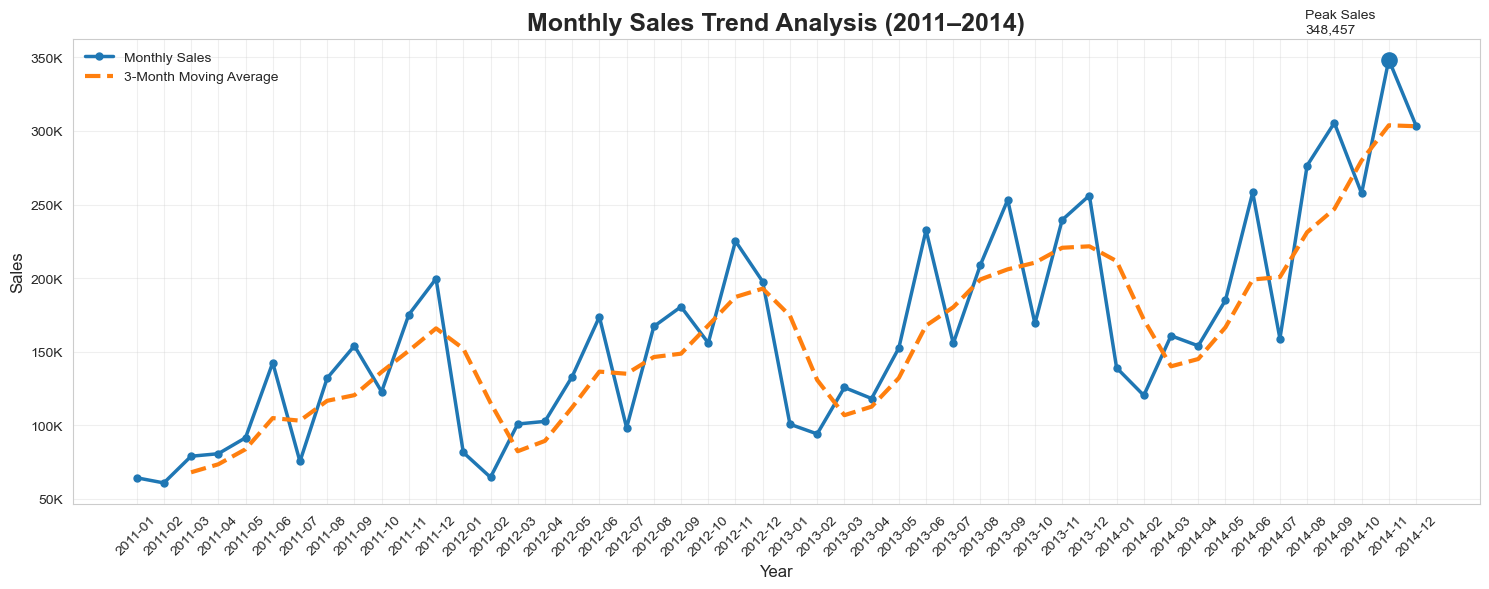

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Convert sales column to numeric
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

# Monthly sales aggregation
monthly_sales = (
    df.groupby(df['order_date'].dt.to_period('M'))['sales']
    .sum()
    .reset_index()
)

monthly_sales['order_date'] = monthly_sales['order_date'].astype(str)

# 3-Month Moving Average
monthly_sales['rolling_avg'] = monthly_sales['sales'].rolling(3).mean()

# Find peak sales point
max_idx = monthly_sales['sales'].idxmax()

# Professional styling
sns.set_style("whitegrid")

plt.figure(figsize=(15,6))

# Monthly Sales Line
plt.plot(
    monthly_sales['order_date'],
    monthly_sales['sales'],
    linewidth=2.5,
    marker='o',
    markersize=5,
    label='Monthly Sales'
)

# Moving Average Line
plt.plot(
    monthly_sales['order_date'],
    monthly_sales['rolling_avg'],
    linestyle='--',
    linewidth=3,
    label='3-Month Moving Average'
)

# Peak Point Highlight
plt.scatter(
    monthly_sales.loc[max_idx, 'order_date'],
    monthly_sales.loc[max_idx, 'sales'],
    s=120,
    zorder=5
)

# Peak Annotation
plt.annotate(
    f"Peak Sales\n{monthly_sales.loc[max_idx,'sales']:,.0f}",
    (
        monthly_sales.loc[max_idx,'order_date'],
        monthly_sales.loc[max_idx,'sales']
    ),
    xytext=(-60,20),
    textcoords='offset points'
)

# Titles and Labels
plt.title(
    'Monthly Sales Trend Analysis (2011–2014)',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Sales', fontsize=12)

# Format Y-axis in K
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

# Rotate X labels
plt.xticks(rotation=45)

# Legend
plt.legend(frameon=False)

# Grid
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

Sales increased gradually from 2011 to 2014.

Some months show sudden drops and spikes, but the overall trend remains positive.

The highest sales were recorded near the end of 2014.

The moving average line shows that business performance improved steadily over time.

## Analysis 2: Profit by Category

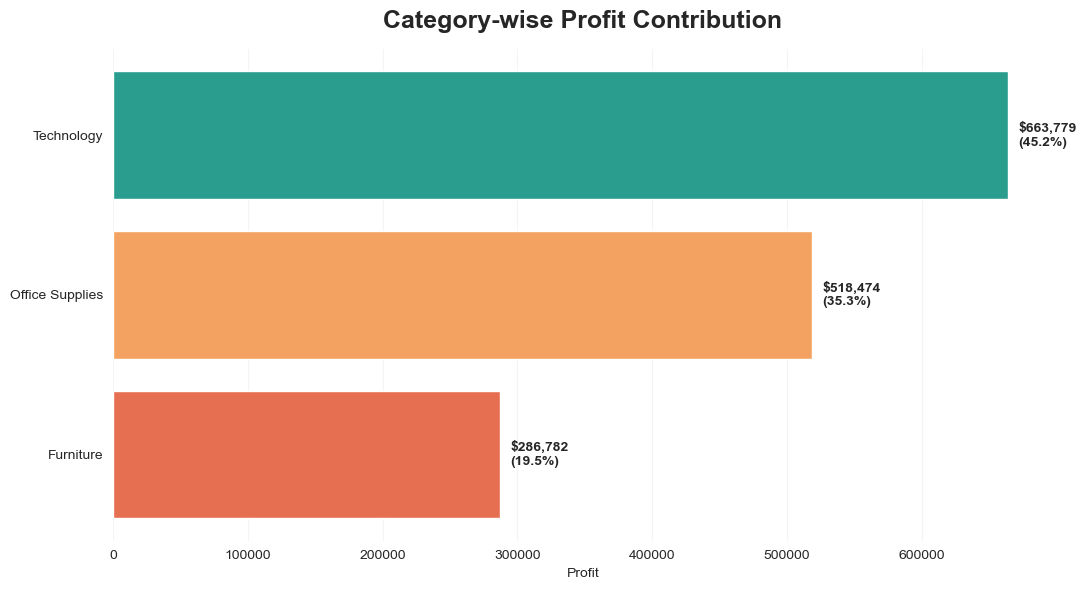

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

profit_by_category = (
    df.groupby('category')['profit']
    .sum()
    .sort_values()
)

total_profit = profit_by_category.sum()

colors = ['#E76F51','#F4A261','#2A9D8F']

plt.figure(figsize=(11,6))
sns.set_style("white")

bars = plt.barh(
    profit_by_category.index,
    profit_by_category.values,
    color=colors
)

for i, value in enumerate(profit_by_category.values):
    
    pct = (value / total_profit) * 100
    
    plt.text(
        value + 8000,
        i,
        f"${value:,.0f}\n({pct:.1f}%)",
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "Category-wise Profit Contribution",
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel("Profit")
plt.ylabel("")

plt.grid(axis='x', alpha=0.2)

sns.despine(left=True,bottom=True)

plt.tight_layout()
plt.show()

### Observation

Technology contributed the largest share of overall profit, accounting for approximately 45% of total profit.

Office Supplies was the second most profitable category and generated a substantial contribution to overall earnings.

Furniture remained profitable but contributed significantly less profit compared to the other two categories.

## Analysis 3: Top 10 Products by Sales

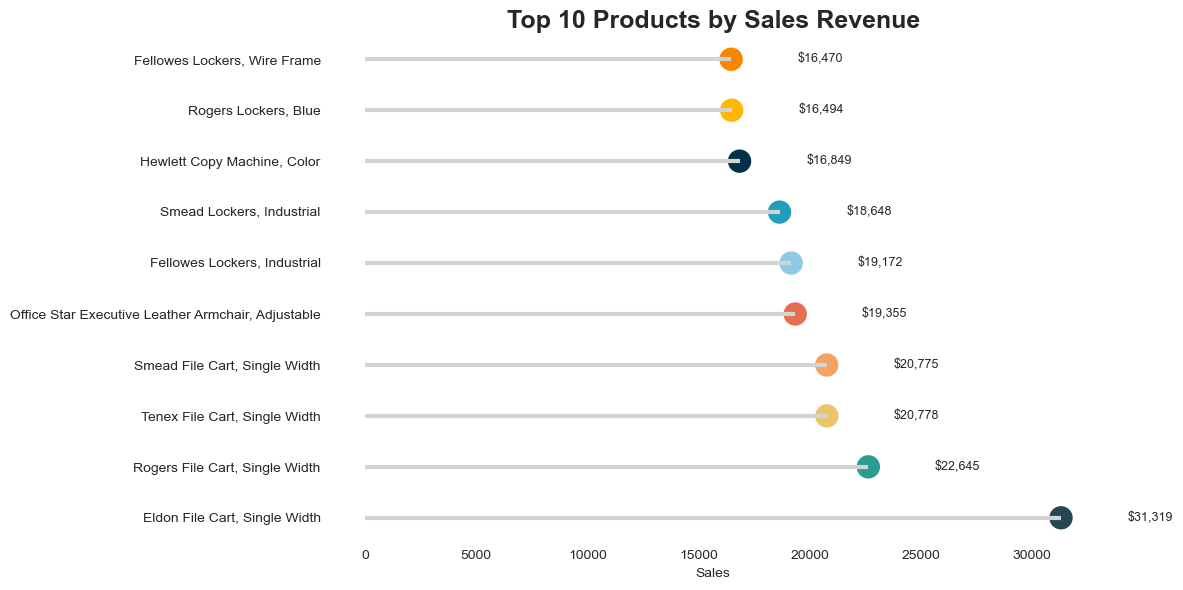

In [42]:
top_products = (
    df.groupby('product_name')['sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12,6))

colors = [
    '#264653','#2A9D8F','#E9C46A','#F4A261','#E76F51',
    '#8ECAE6','#219EBC','#023047','#FFB703','#FB8500'
]

plt.hlines(
    y=top_products['product_name'],
    xmin=0,
    xmax=top_products['sales'],
    color='lightgray',
    linewidth=3
)

plt.scatter(
    top_products['sales'],
    top_products['product_name'],
    s=250,
    c=colors
)

for i, value in enumerate(top_products['sales']):
    plt.text(
        value + 3000,
        i,
        f"${value:,.0f}",
        va='center',
        fontsize=9
    )

plt.title(
    'Top 10 Products by Sales Revenue',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Sales')
plt.ylabel('')

sns.despine(left=True,bottom=True)

plt.tight_layout()
plt.show()

### Observation

The top-selling products generated significantly higher revenue than the remaining products.

A small number of products contributed a major share of total sales.

The sales distribution indicates that a few high-performing products drive business revenue.

## Analysis 4: Products Generating Highest Loss

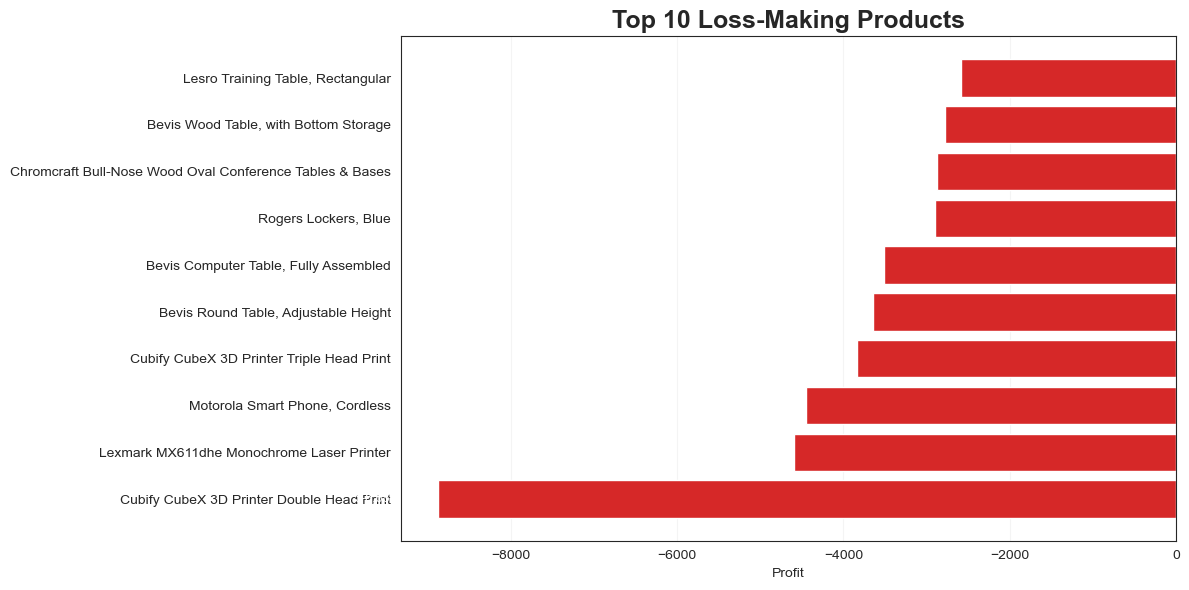

In [43]:
loss_products = (
    df.groupby('product_name')['profit']
      .sum()
      .sort_values()
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12,6))

bars = plt.barh(
    loss_products['product_name'],
    loss_products['profit'],
    color='#D62828'
)

for bar in bars:
    plt.text(
        bar.get_width()-1000,
        bar.get_y()+bar.get_height()/2,
        f"${bar.get_width():,.0f}",
        va='center',
        fontsize=9,
        color='white'
    )

plt.title(
    'Top 10 Loss-Making Products',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Profit')
plt.ylabel('')

plt.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

### Observation

Several products generated consistent losses despite being sold frequently.

These products should be reviewed for pricing, discount policies, and operational costs.

Reducing losses from these products could improve overall profitability.

## Analysis 5: Sales vs Profit Relationship


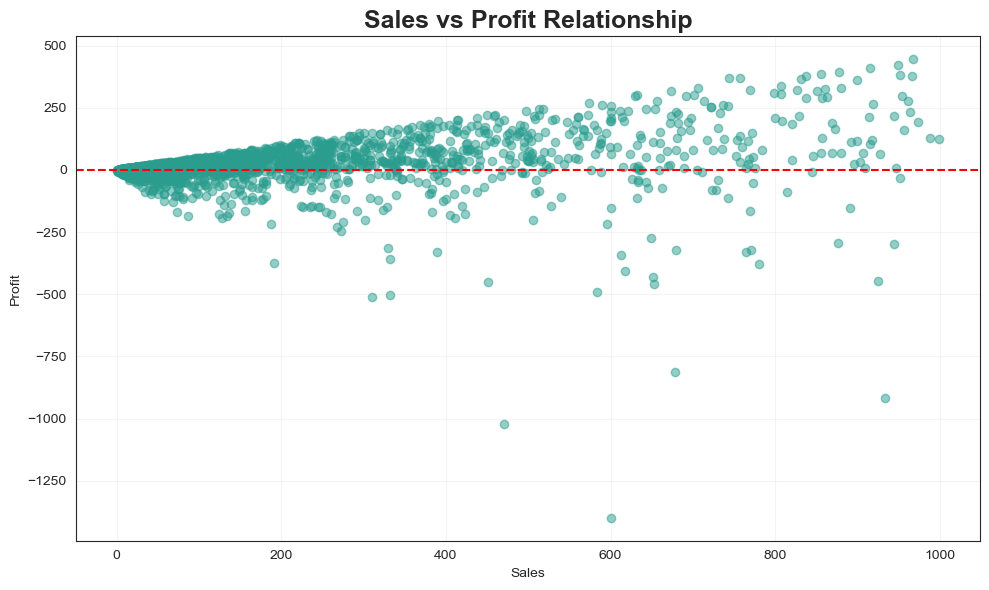

In [44]:
sample_df = df.sample(3000, random_state=42)

plt.figure(figsize=(10,6))

plt.scatter(
    sample_df['sales'],
    sample_df['profit'],
    alpha=0.5,
    color='#2A9D8F'
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title(
    'Sales vs Profit Relationship',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Sales')
plt.ylabel('Profit')

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Observation

Higher sales generally lead to higher profits, indicating a positive relationship.

However, some high-sales transactions still resulted in losses.

This suggests that discounts and costs can significantly impact profitability.

## Analysis 6: Regional Profit Analysis

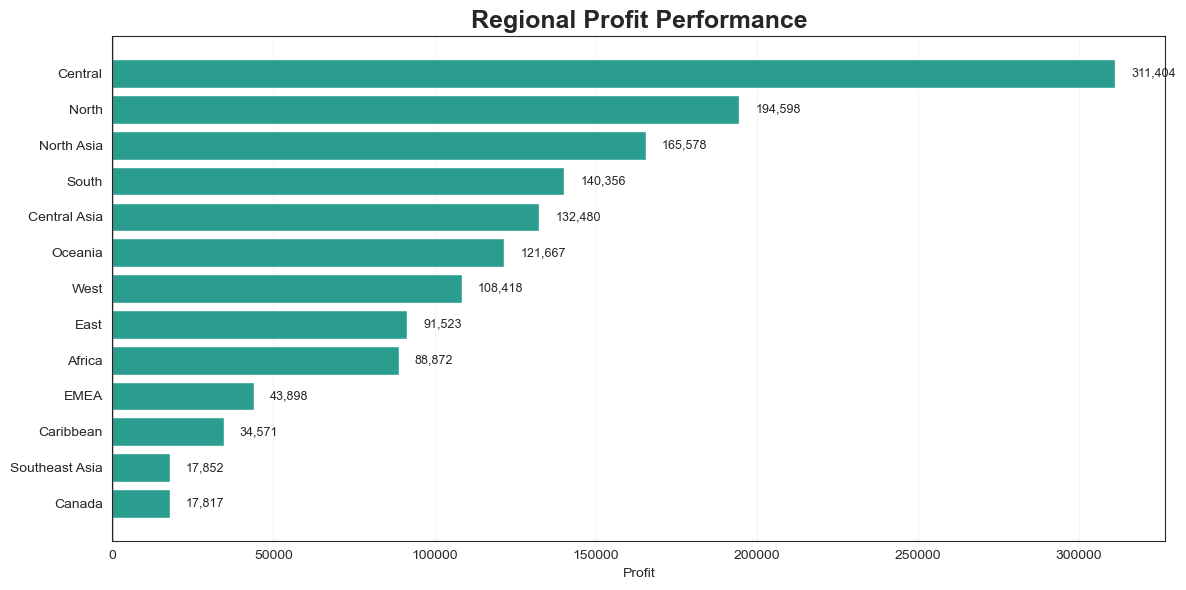

In [45]:
region_profit = (
    df.groupby('region')['profit']
      .sum()
      .sort_values()
      .reset_index()
)

colors = [
    '#D62828' if x < 0 else '#2A9D8F'
    for x in region_profit['profit']
]

plt.figure(figsize=(12,6))

bars = plt.barh(
    region_profit['region'],
    region_profit['profit'],
    color=colors
)

for bar in bars:
    value = bar.get_width()

    plt.text(
        value + (5000 if value > 0 else -25000),
        bar.get_y() + bar.get_height()/2,
        f"{value:,.0f}",
        va='center',
        fontsize=9
    )

plt.axvline(
    x=0,
    color='black',
    linewidth=1
)

plt.title(
    'Regional Profit Performance',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Profit')
plt.ylabel('')

plt.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

### Observation

Profitability varies significantly across regions.

Some regions generated substantially higher profits and acted as major revenue contributors.

Regions with relatively lower profits may require improvements in pricing, operations, or customer acquisition strategies.

## Analysis 7: Discount vs Profit Impact

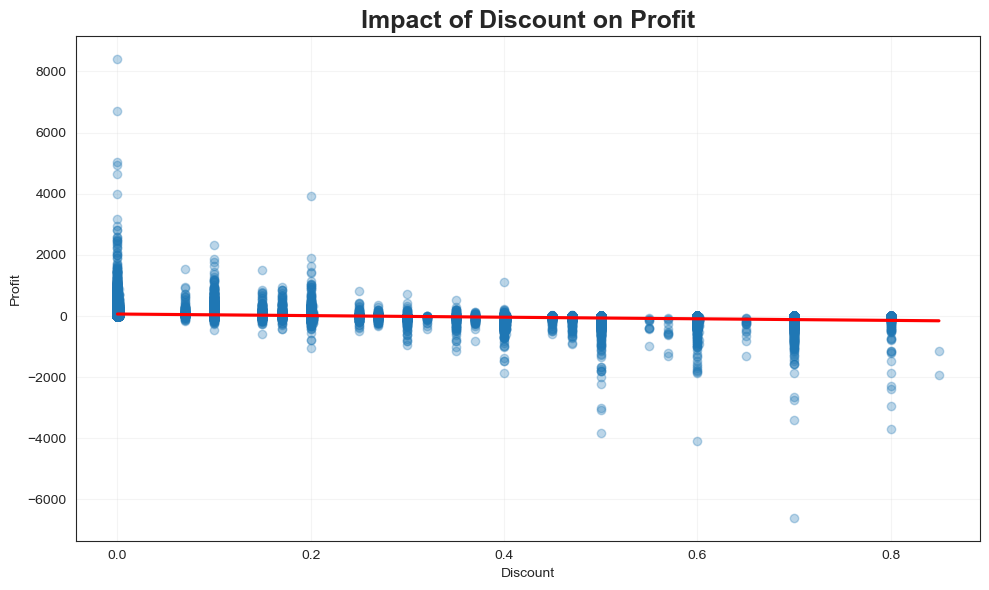

In [46]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='discount',
    y='profit',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title(
    'Impact of Discount on Profit',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Discount')
plt.ylabel('Profit')

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Observation

Most profitable transactions were recorded at lower discount levels.

As the discount percentage increased, profitability generally declined, indicating a negative relationship between discount and profit.

Several transactions with discounts above 50% resulted in significant losses.

This suggests that aggressive discounting strategies may negatively impact overall business profitability.

## Key Findings

1. Sales showed a consistent upward trend from 2011 to 2014.

2. Technology was the most profitable category, contributing the highest share of total profit.

3. A small number of products generated a significant portion of total sales.

4. Certain products consistently generated losses and require business review.

5. Higher sales generally resulted in higher profits.

6. Profitability varied across regions, indicating market-specific performance differences.

7. Higher discounts were associated with lower profits and increased risk of losses.

## Conclusion

The analysis revealed strong sales growth between 2011 and 2014, with Technology emerging as the most profitable category. While several products and regions performed exceptionally well, a number of products generated recurring losses. The study also showed that excessive discounting negatively affected profitability. These insights can help businesses improve pricing strategies, optimize product portfolios, and focus on high-performing regions to maximize profit.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook